<a href="https://colab.research.google.com/github/JuanMuneton87/Fund_Ciencia_de_Datos/blob/main/py_Juan_Diego_Muneton_Herrera_Proyecto_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from wordcloud import WordCloud
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)
from scipy.stats import boxcox
from sklearn.preprocessing import PowerTransformer
from scipy.stats import zscore
from sklearn.cluster import KMeans

In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "JuanHerrera1987",\r\n  "key": "KGAT_753893a9829fba323aa31ab5358df39f"\r\n}'}

In [5]:
# Configurar Kaggle
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Descargar dataset
!kaggle datasets download -d ggtejas/tmdb-imdb-merged-movies-dataset

# Descomprimir
!unzip tmdb-imdb-merged-movies-dataset.zip

# Cargar dataset
df = pd.read_csv('TMDB  IMDB Movies Dataset.csv')
df.head()

Dataset URL: https://www.kaggle.com/datasets/ggtejas/tmdb-imdb-merged-movies-dataset
License(s): CC-BY-NC-SA-4.0
100% 126M/126M [00:00<00:00, 158MB/s]

Archive:  tmdb-imdb-merged-movies-dataset.zip
  inflating: TMDB  IMDB Movies Dataset.csv  


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,genres,production_companies,production_countries,spoken_languages,keywords,directors,writers,averageRating,numVotes,cast
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",Christopher Nolan,Christopher Nolan,8.8,2819398,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan",8.7,2532287,"Matthew McConaughey, Anne Hathaway, Michael Ca..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Go...",9.1,3170429,"Christian Bale, Heath Ledger, Aaron Eckhart, M..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",James Cameron,James Cameron,7.9,1498684,"Sam Worthington, Zoe Saldaña, Sigourney Weaver..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",Joss Whedon,"Joss Whedon, Zak Penn",8.0,1559108,"Robert Downey Jr., Chris Evans, Mark Ruffalo, ..."


In [6]:
df_original = df.copy()

#PREGUNTA

¿Cómo se relacionan el presupuesto, la popularidad y las valoraciones de las películas con sus ingresos en taquilla?

Variable objetivo: revenue.

Variables explicativas: budget, popularity, vote_average, vote_count.

Variables complementarias: directors, cast, original_language, release_year, runtime, main_genre.

#Exploración inicial del dataset

In [7]:
# Dimensiones del dataset
df.shape

(438339, 29)

In [8]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438339 entries, 0 to 438338
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    438339 non-null  int64  
 1   title                 438339 non-null  object 
 2   vote_average          438339 non-null  float64
 3   vote_count            438339 non-null  int64  
 4   status                438339 non-null  object 
 5   release_date          415945 non-null  object 
 6   revenue               438339 non-null  int64  
 7   runtime               438339 non-null  int64  
 8   adult                 438339 non-null  bool   
 9   backdrop_path         185734 non-null  object 
 10  budget                438339 non-null  int64  
 11  homepage              54931 non-null   object 
 12  tconst                438339 non-null  object 
 13  original_language     438339 non-null  object 
 14  original_title        438339 non-null  object 
 15  

In [9]:
#Resumen estadístico del dataset
df.describe()

,id,vote_average,vote_count,revenue,runtime,budget,popularity,averageRating,numVotes
count,4.383390e+05,438339.000000,438339.000000,4.383390e+05,438339.000000,4.383390e+05,438339.000000,438339.000000,4.383390e+05
mean,4.982447e+05,3.586333,48.619155,1.661143e+06,66.416390,6.497561e+05,2.184334,6.222137,3.136653e+03
std,3.698885e+05,3.152506,511.482330,2.619817e+07,64.206995,7.410782e+06,11.316263,1.311354,3.413424e+04
min,2.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000,5.000000e+00
25%,2.111850e+05,0.000000,0.000000,0.000000e+00,15.000000,0.000000e+00,0.600000,5.400000,2.400000e+01
50%,4.211170e+05,4.517000,1.000000,0.000000e+00,80.000000,0.000000e+00,0.850000,6.300000,7.100000e+01
75%,7.165785e+05,6.200000,5.000000,0.000000e+00,96.000000,0.000000e+00,1.649000,7.100000,3.290000e+02
max,1.700822e+06,10.000000,34495.000000,2.923706e+09,14400.000000,8.880000e+08,2994.357000,10.000000,3.191059e+06


In [10]:
#Identificar valores nulos
df.isnull().sum().sort_values(ascending=False)

,0
homepage,383408
tagline,345731
keywords,267442
backdrop_path,252605
production_companies,176056
production_countries,117323
spoken_languages,105789
genres,80776
poster_path,76779
cast,69028


In [11]:
# Filtrar registros con valores financieros válidos
df_movies = df[
    (df['budget'] > 0) &
    (df['revenue'] > 0)
].copy()

In [12]:
#Filtrar duración de películas
df_movies = df_movies[
    (df_movies['runtime'] >= 40) &
    (df_movies['runtime'] <= 300)
]

In [13]:
#Verificar registros duplicados
df_movies.duplicated().sum()

np.int64(0)

In [14]:
#Conversión de fechas y extracción del año
df_movies['release_date'] = pd.to_datetime(
    df_movies['release_date'],
    errors='coerce'
)

df_movies['release_year'] = (
    df_movies['release_date']
    .dt.year
)

In [15]:
#Evaluación de asimetría
variables_numericas = [
    'budget',
    'revenue',
    'popularity',
    'vote_average',
    'averageRating',
    'runtime'
]

for col in variables_numericas:
    print(f"{col}: {df_movies[col].skew():.2f}")

budget: 3.30
revenue: 5.85
popularity: 28.83
vote_average: -2.17
averageRating: -0.78
runtime: 1.16


In [16]:
df_movies.describe()

,id,vote_average,vote_count,release_date,revenue,runtime,budget,popularity,averageRating,numVotes,release_year
count,9.923000e+03,9923.000000,9923.000000,9885,9.923000e+03,9923.000000,9.923000e+03,9923.000000,9923.000000,9.923000e+03,9885.000000
mean,1.596434e+05,6.216612,1540.916557,2001-05-03 21:18:44.248862080,6.715174e+07,108.979240,2.393269e+07,19.512300,6.349320,9.547940e+04,2000.806677
min,5.000000e+00,0.000000,0.000000,1913-11-24 00:00:00,1.000000e+00,40.000000,1.000000e+00,0.000000,1.100000,8.000000e+00,1913.000000
25%,1.068200e+04,5.785000,71.000000,1994-09-23 00:00:00,2.000000e+06,94.000000,2.200000e+06,6.855500,5.700000,5.128500e+03,1994.000000
50%,3.668300e+04,6.400000,413.000000,2006-10-14 00:00:00,1.330000e+07,105.000000,1.000000e+07,13.194000,6.500000,2.610800e+04,2006.000000
75%,2.588725e+05,7.000000,1563.000000,2014-03-07 00:00:00,5.979096e+07,120.000000,2.800000e+07,20.628500,7.100000,9.797600e+04,2014.000000
max,1.657350e+06,10.000000,34495.000000,2024-01-31 00:00:00,2.923706e+09,279.000000,4.600000e+08,2994.357000,9.600000,3.191059e+06,2024.000000
std,2.376801e+05,1.434226,2987.244414,NaN,1.570431e+08,22.475891,3.819822e+07,61.854618,1.123795,1.985146e+05,18.861128


In [17]:
# Verificar dimensiones
df_movies.shape

(9923, 30)

In [18]:
df_clean = df_movies.copy()

Algunas variables textuales presentan una alta proporción de valores faltantes, particularmente homepage, tagline y keywords, lo cual limita su utilidad analítica dentro del estudio principal.

Se observó una alta proporción de registros con valores iguales a cero en las variables budget y revenue. Debido a que estos valores pueden corresponder a información no reportada o incompleta, se construyó un subconjunto de datos con registros financieros válidos para realizar los análisis relacionados con desempeño económico.

Se filtraron valores extremos en la variable runtime debido a la presencia de duraciones poco representativas para películas comerciales, lo que podría afectar la interpretación estadística y visual de los datos.

#Primeras visualizaciones

#Correlaciones

In [19]:
#Matriz de correlación
corr = df_movies[
    [
        'budget',
        'revenue',
        'popularity',
        'vote_average',
        'averageRating'
    ]
].corr()

corr

,budget,revenue,popularity,vote_average,averageRating
budget,1.000000,0.743544,0.240517,0.123427,0.060212
revenue,0.743544,1.000000,0.228568,0.174241,0.172496
popularity,0.240517,0.228568,1.000000,0.114346,0.055004
vote_average,0.123427,0.174241,0.114346,1.000000,0.563032
averageRating,0.060212,0.172496,0.055004,0.563032,1.000000


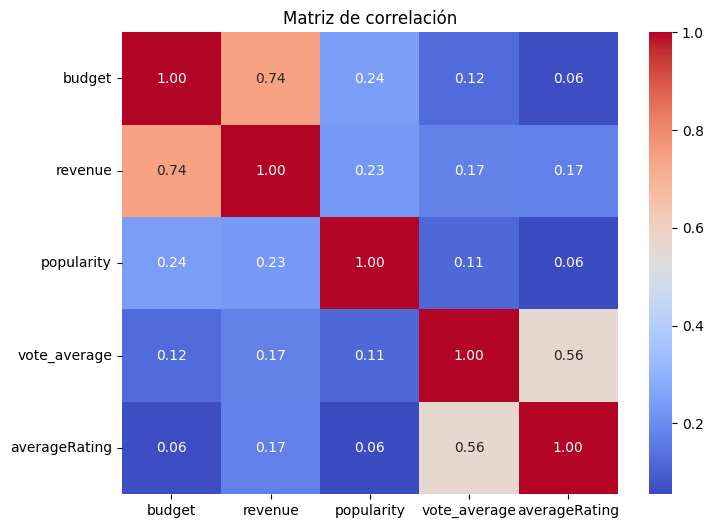

In [20]:
#Visualización de correlaciones
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de correlación')

plt.show()

#Histogramas

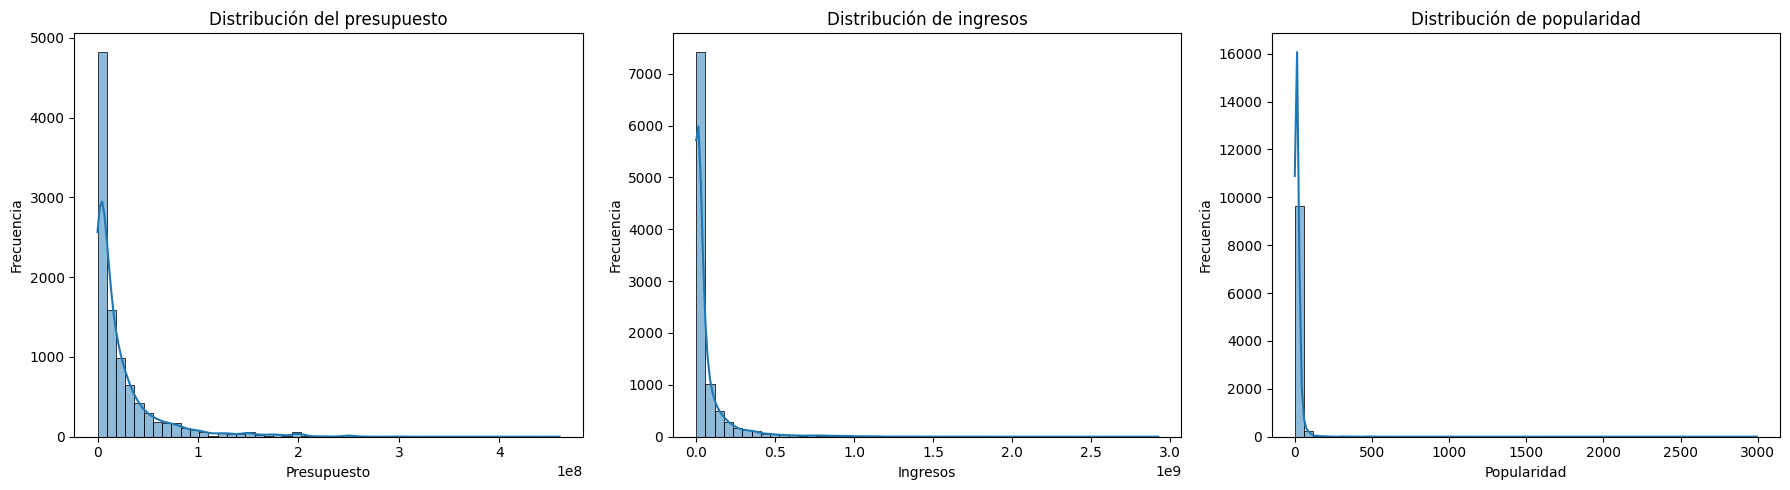

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Histograma Budget
sns.histplot(
    df_movies['budget'],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title('Distribución del presupuesto')
axes[0].set_xlabel('Presupuesto')
axes[0].set_ylabel('Frecuencia')

# Histograma Revenue
sns.histplot(
    df_movies['revenue'],
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title('Distribución de ingresos')
axes[1].set_xlabel('Ingresos')
axes[1].set_ylabel('Frecuencia')

# Histograma Popularity
sns.histplot(
    df_movies['popularity'],
    bins=50,
    kde=True,
    ax=axes[2]
)

axes[2].set_title('Distribución de popularidad')
axes[2].set_xlabel('Popularidad')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()

plt.show()

#Estadísticas descriptivas

In [22]:
#Construcción de tabla estadística descriptiva
variables = [
    'budget',
    'revenue',
    'popularity',
    'vote_average',
    'averageRating',
    'runtime'
]

tabla_estadistica = pd.DataFrame()

for col in variables:

    tabla_estadistica.loc[col, 'Media'] = df_movies[col].mean()

    tabla_estadistica.loc[col, 'Mediana'] = df_movies[col].median()

    tabla_estadistica.loc[col, 'Desv_Std'] = df_movies[col].std()

    tabla_estadistica.loc[col, 'Varianza'] = df_movies[col].var()

    tabla_estadistica.loc[col, 'Min'] = df_movies[col].min()

    tabla_estadistica.loc[col, 'Max'] = df_movies[col].max()

    tabla_estadistica.loc[col, 'Rango'] = (
        df_movies[col].max() - df_movies[col].min()
    )

    tabla_estadistica.loc[col, 'Q1_25%'] = (
        df_movies[col].quantile(0.25)
    )

    tabla_estadistica.loc[col, 'Q2_50%'] = (
        df_movies[col].quantile(0.50)
    )

    tabla_estadistica.loc[col, 'Q3_75%'] = (
        df_movies[col].quantile(0.75)
    )

    tabla_estadistica.loc[col, 'P90'] = (
        df_movies[col].quantile(0.90)
    )

    tabla_estadistica.loc[col, 'P95'] = (
        df_movies[col].quantile(0.95)
    )

    tabla_estadistica.loc[col, 'IQR'] = (
        df_movies[col].quantile(0.75)
        -
        df_movies[col].quantile(0.25)
    )

    tabla_estadistica.loc[col, 'Skewness'] = (
        df_movies[col].skew()
    )

    tabla_estadistica.loc[col, 'Kurtosis'] = (
        df_movies[col].kurt()
    )

# Redondear resultados
tabla_estadistica = tabla_estadistica.round(2)

tabla_estadistica

,Media,Mediana,Desv_Std,Varianza,Min,Max,Rango,Q1_25%,Q2_50%,Q3_75%,P90,P95,IQR,Skewness,Kurtosis
budget,23932688.50,10000000.00,3.819822e+07,1.459104e+15,1.0,4.600000e+08,4.600000e+08,2200000.00,10000000.00,28000000.00,64000000.0,1.000000e+08,25800000.00,3.30,14.90
revenue,67151738.74,13300000.00,1.570431e+08,2.466254e+16,1.0,2.923706e+09,2.923706e+09,2000000.00,13300000.00,59790964.50,176392787.6,3.128377e+08,57790964.50,5.85,54.27
popularity,19.51,13.19,6.185000e+01,3.825990e+03,0.0,2.994360e+03,2.994360e+03,6.86,13.19,20.63,33.8,4.708000e+01,13.77,28.83,1089.99
vote_average,6.22,6.40,1.430000e+00,2.060000e+00,0.0,1.000000e+01,1.000000e+01,5.78,6.40,7.00,7.5,7.810000e+00,1.21,-2.17,7.77
averageRating,6.35,6.50,1.120000e+00,1.260000e+00,1.1,9.600000e+00,8.500000e+00,5.70,6.50,7.10,7.6,8.000000e+00,1.40,-0.78,1.28
runtime,108.98,105.00,2.248000e+01,5.051700e+02,40.0,2.790000e+02,2.390000e+02,94.00,105.00,120.00,138.0,1.510000e+02,26.00,1.16,2.92


La correlación entre budget y revenue fue de 0.74, evidenciando que las películas con mayores presupuestos tienden a generar mayores ingresos en taquilla, aunque esto no implica causalidad directa.

Por otro lado, popularity y revenue presentan una correlación positiva baja (0.23), lo que indica que una mayor popularidad puede asociarse con mayores ingresos, pero existen otros factores relevantes en el desempeño comercial. Asimismo, la relación entre las valoraciones promedio y los ingresos es positiva pero débil, sugiriendo que una mejor recepción del público no garantiza necesariamente mayores ganancias.

Finalmente, vote_average y averageRating muestran una correlación moderada positiva (0.56), reflejando cierta consistencia entre las valoraciones registradas en TMDB e IMDb.

El análisis evidencia una fuerte concentración del éxito comercial en la industria cinematográfica, donde unas pocas películas acumulan presupuestos, ingresos y niveles de popularidad excepcionalmente altos, mientras la mayoría presenta valores considerablemente menores. Esto explica la alta asimetría y la presencia de valores extremos en las variables financieras y de popularidad.

En contraste, las variables de valoración y duración muestran comportamientos más estables y homogéneos, lo que sugiere que la percepción del público y la duración de las películas tienden a mantenerse dentro de rangos más consistentes.

La presencia de valores extremos en las variable revenue, budget y popularity, causan un sesgo positivo y distribuciones no normales. Lo que justifica la creación de versiones logarítmicas de estas variables.

In [23]:
#Transformación logarítmica
df_movies['log_budget'] = np.log1p(df_movies['budget'])

df_movies['log_revenue'] = np.log1p(df_movies['revenue'])

df_movies['log_popularity'] = np.log1p(df_movies['popularity'])

In [24]:
#Evaluación de asimetría
variables_log = [
    'log_budget',
    'log_revenue',
    'log_popularity'
]

for col in variables_log:
    print(f"{col}: {df_movies[col].skew():.2f}")

log_budget: -2.18
log_revenue: -1.55
log_popularity: -0.16


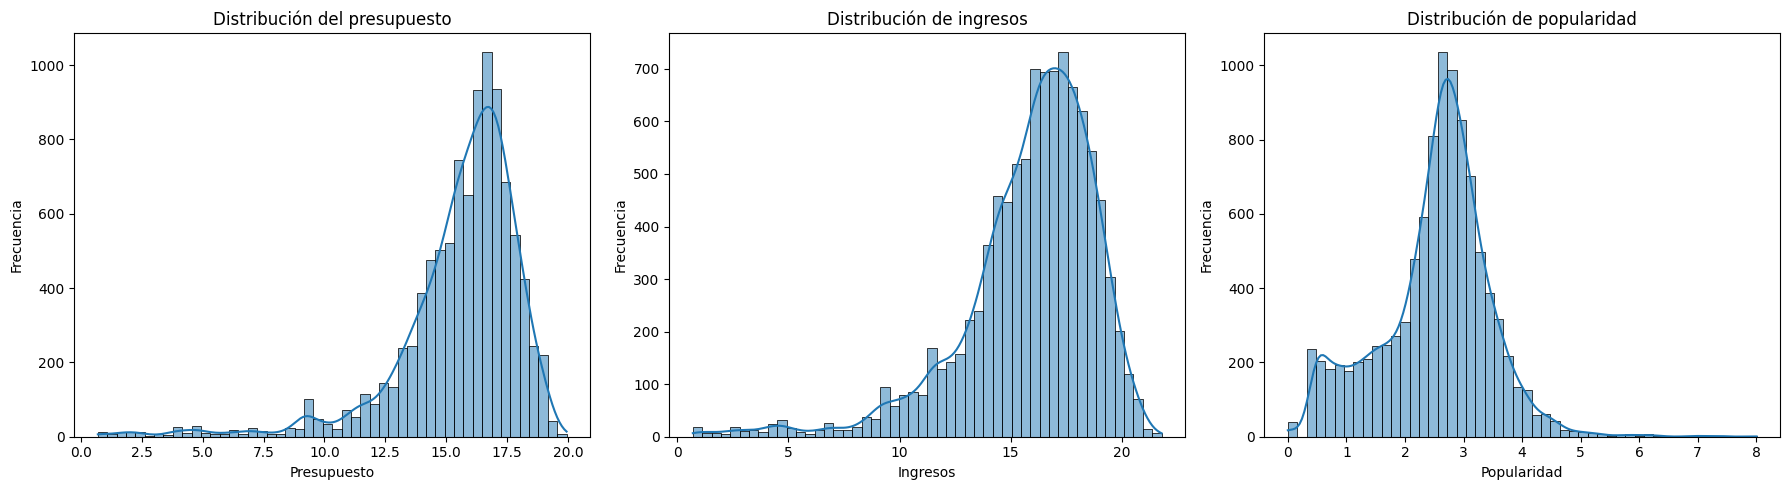

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Histograma Budget
sns.histplot(
    df_movies['log_budget'],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title('Distribución del presupuesto')
axes[0].set_xlabel('Presupuesto')
axes[0].set_ylabel('Frecuencia')

# Histograma Revenue
sns.histplot(
    df_movies['log_revenue'],
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title('Distribución de ingresos')
axes[1].set_xlabel('Ingresos')
axes[1].set_ylabel('Frecuencia')

# Histograma Popularity
sns.histplot(
    df_movies['log_popularity'],
    bins=50,
    kde=True,
    ax=axes[2]
)

axes[2].set_title('Distribución de popularidad')
axes[2].set_xlabel('Popularidad')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()

plt.show()

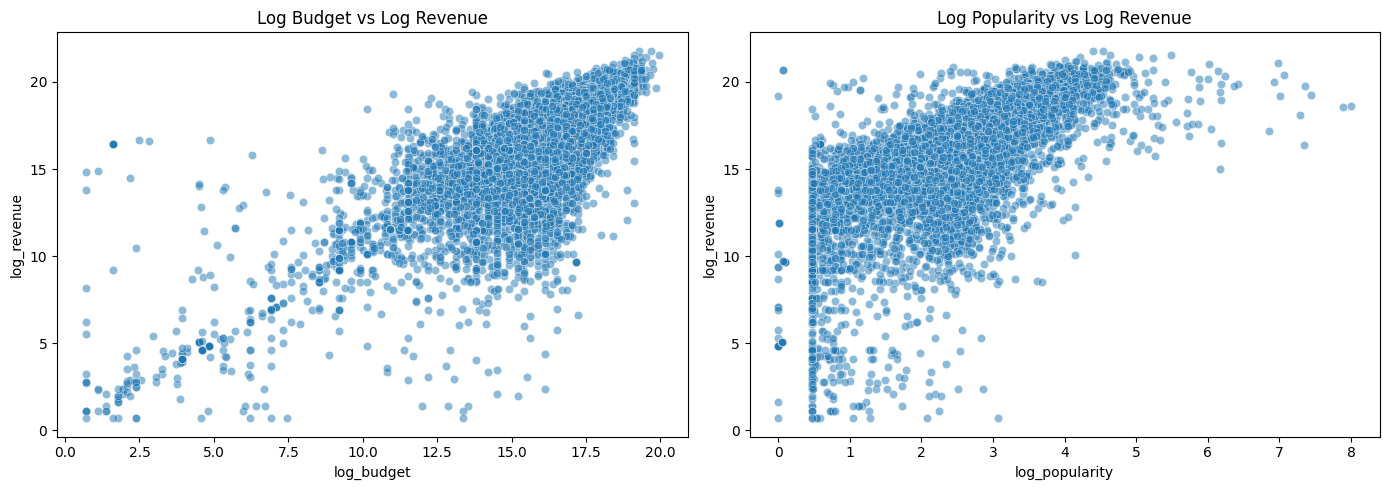

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Budget vs Revenue
sns.scatterplot(
    data=df_movies,
    x='log_budget',
    y='log_revenue',
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title('Log Budget vs Log Revenue')

# Popularity vs Revenue
sns.scatterplot(
    data=df_movies,
    x='log_popularity',
    y='log_revenue',
    alpha=0.5,
    ax=axes[1]
)

axes[1].set_title('Log Popularity vs Log Revenue')

plt.tight_layout()

plt.show()

Las transformaciones logarítmicas redujeron significativamente la asimetría y el impacto de los valores extremos en las variables financieras y de popularidad, evidenciando que gran parte de la variabilidad inicial estaba concentrada en unas pocas películas con resultados excepcionalmente altos. Esto permitió obtener distribuciones más estables y adecuadas para análisis posteriores.

A partir de los scatterplots, se observa además que el presupuesto mantiene una relación más consistente con los ingresos en taquilla, lo que sugiere que una mayor inversión suele asociarse con mejores resultados comerciales. En contraste, la popularidad presenta una relación más débil y dispersa, indicando que no explica por sí sola el éxito financiero de una película.

In [27]:
variables_escalado = [
    'budget',
    'revenue',
    'popularity'
]

# Copia de trabajo
df_scaling = df_movies.copy()

# Inicializar escaladores
standard_scaler = StandardScaler()

minmax_scaler = MinMaxScaler()

robust_scaler = RobustScaler()

# Aplicar transformaciones
df_scaling_std = pd.DataFrame(
    standard_scaler.fit_transform(
        df_scaling[variables_escalado]
    ),
    columns=[
        f'{col}_std'
        for col in variables_escalado
    ]
)

df_scaling_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(
        df_scaling[variables_escalado]
    ),
    columns=[
        f'{col}_minmax'
        for col in variables_escalado
    ]
)

df_scaling_robust = pd.DataFrame(
    robust_scaler.fit_transform(
        df_scaling[variables_escalado]
    ),
    columns=[
        f'{col}_robust'
        for col in variables_escalado
    ]
)

# Unir resultados
df_scaling = pd.concat(
    [
        df_scaling.reset_index(drop=True),
        df_scaling_std,
        df_scaling_minmax,
        df_scaling_robust
    ],
    axis=1
)

df_scaling.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,log_popularity,budget_std,revenue_std,popularity_std,budget_minmax,revenue_minmax,popularity_minmax,budget_robust,revenue_robust,popularity_robust
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,4.442086,3.562317,4.829370,1.041845,0.347826,0.282358,0.028037,5.813953,14.054667,5.137443
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,4.950468,3.693220,4.040989,1.951912,0.358696,0.240014,0.046835,6.007752,11.912402,9.224352
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,4.880094,4.216831,5.969405,1.796734,0.402174,0.343591,0.043630,6.782946,17.152481,8.527481
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,4.393609,5.578220,18.190535,0.976851,0.515217,1.000000,0.026694,8.798450,50.360918,4.845567
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,4.595948,5.133150,9.244194,1.270296,0.478261,0.519483,0.032756,8.139535,26.051054,6.163363


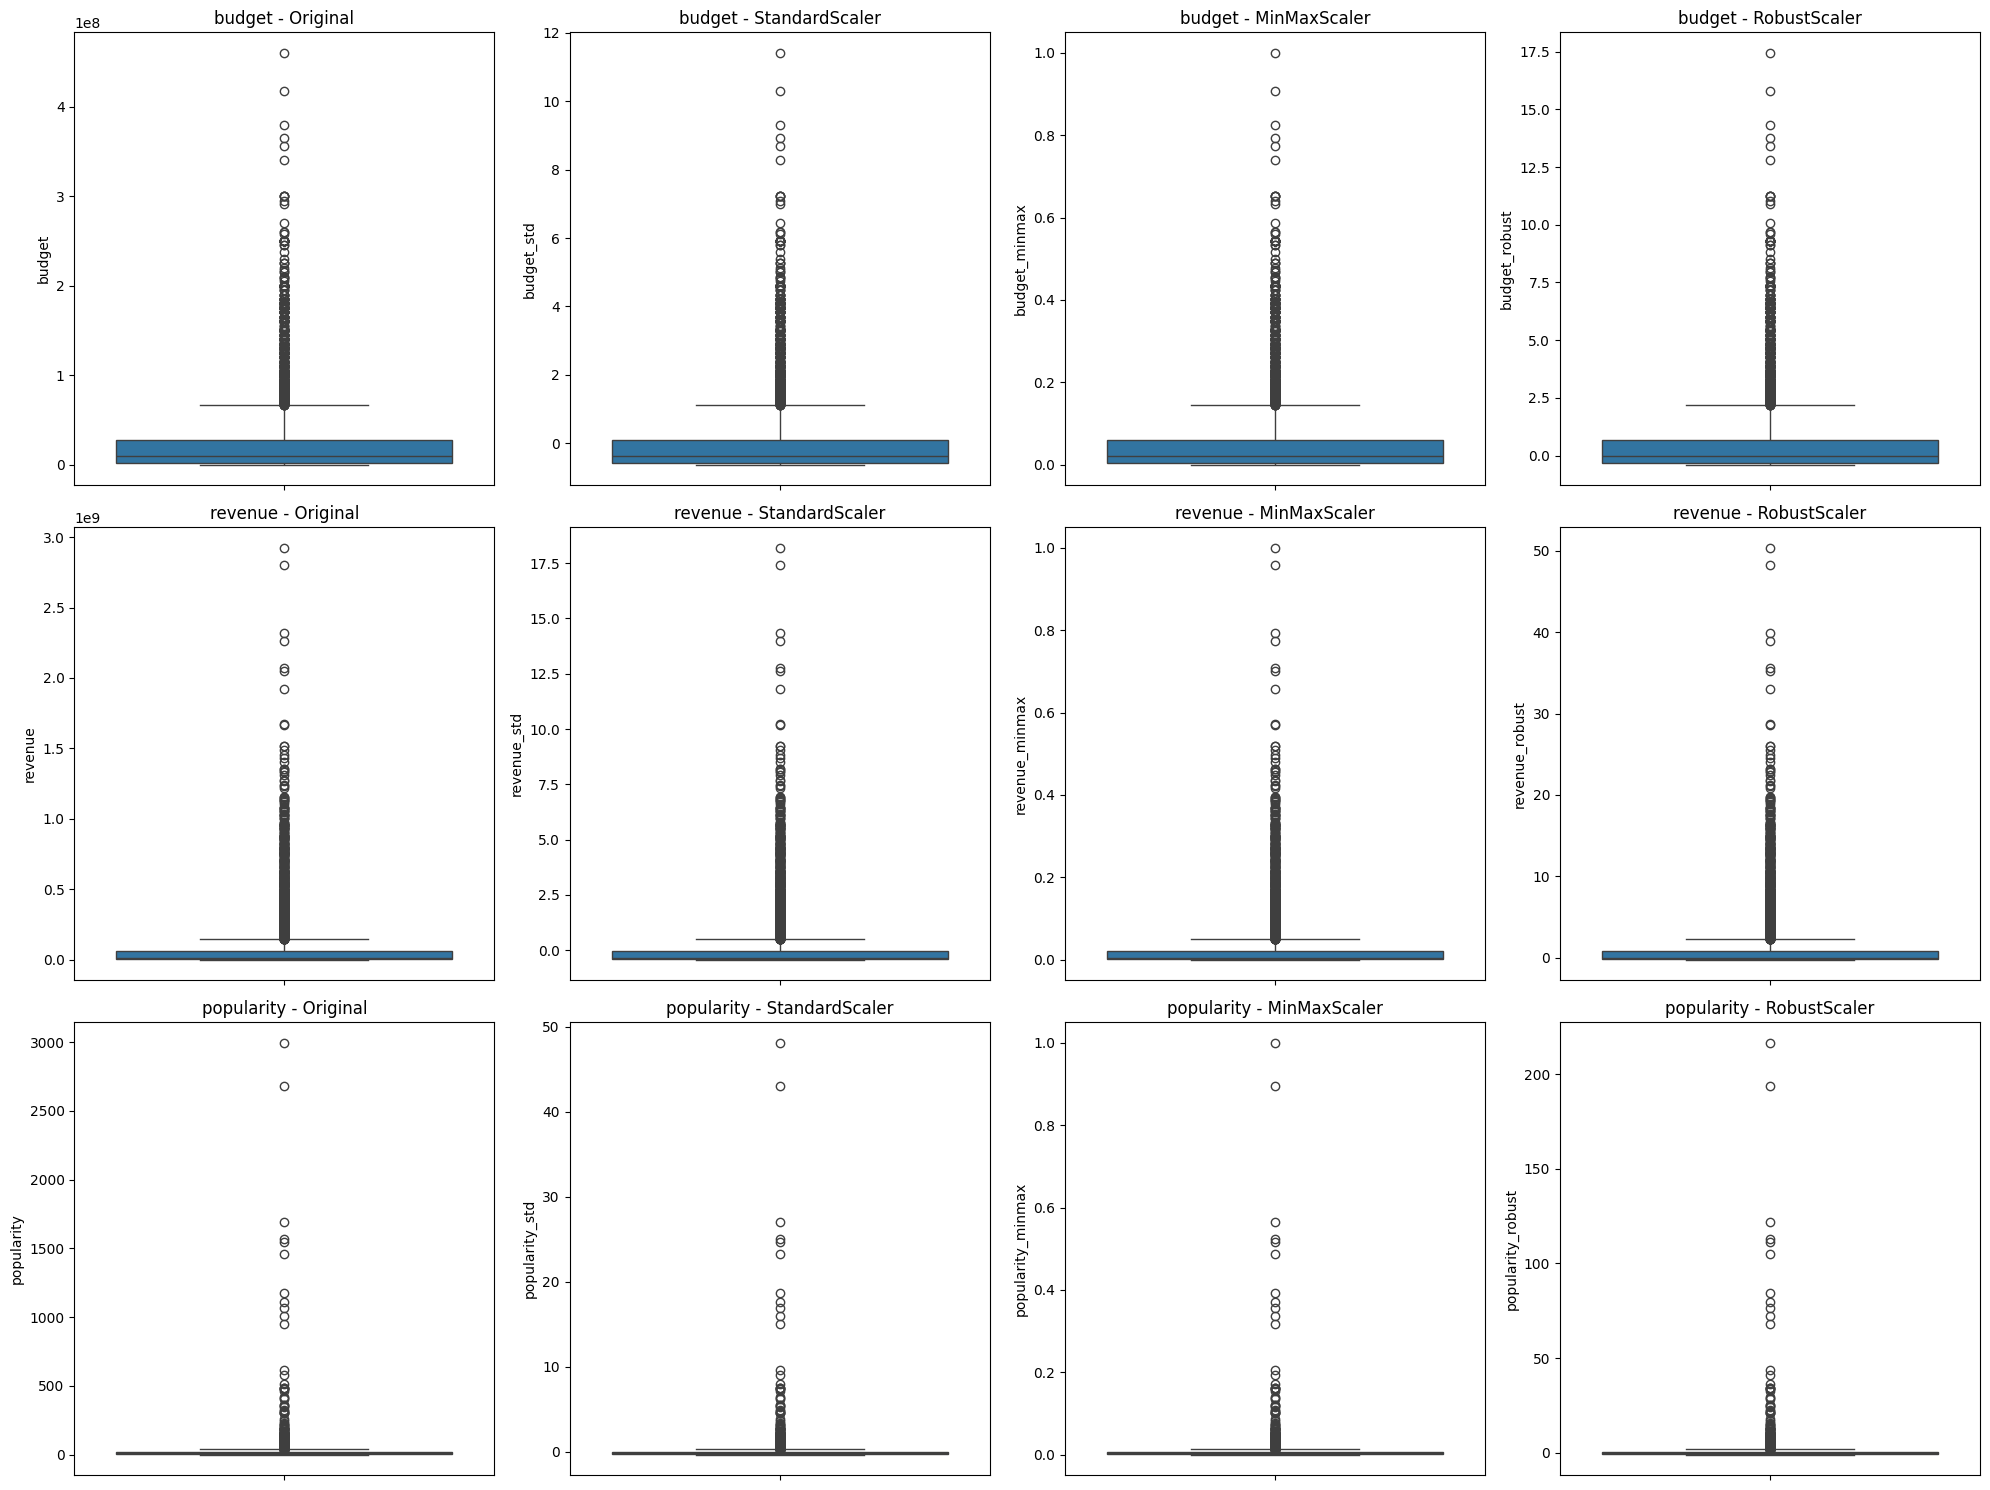

In [28]:
#Comparación de métodos de escalamiento
variables = [
    'budget',
    'revenue',
    'popularity'
]

transformaciones = [
    '',
    '_std',
    '_minmax',
    '_robust'
]

titulos = [
    'Original',
    'StandardScaler',
    'MinMaxScaler',
    'RobustScaler'
]

fig, axes = plt.subplots(
    3,
    4,
    figsize=(20,15)
)

for i, var in enumerate(variables):

    for j, trans in enumerate(transformaciones):

        columna = f'{var}{trans}'

        sns.boxplot(
            y=df_scaling[columna],
            ax=axes[i,j]
        )

        axes[i,j].set_title(
            f'{var} - {titulos[j]}'
        )

plt.tight_layout()

plt.show()

In [29]:
# Tabla comparativa de métodos de escalamiento
variables = [
    'budget',
    'revenue',
    'popularity'
]

transformaciones = [
    '',
    '_std',
    '_minmax',
    '_robust'
]

tabla_scaling = pd.DataFrame()

for var in variables:

    for trans in transformaciones:

        columna = f'{var}{trans}'

        nombre = (
            f'{var}{trans}'
            if trans != ''
            else f'{var}_original'
        )

        tabla_scaling.loc[nombre, 'Media'] = (
            df_scaling[columna].mean()
        )

        tabla_scaling.loc[nombre, 'Desv_Std'] = (
            df_scaling[columna].std()
        )

        tabla_scaling.loc[nombre, 'Min'] = (
            df_scaling[columna].min()
        )

        tabla_scaling.loc[nombre, 'Max'] = (
            df_scaling[columna].max()
        )

tabla_scaling = tabla_scaling.round(2)

tabla_scaling

,Media,Desv_Std,Min,Max
budget_original,23932688.50,3.819822e+07,1.00,4.600000e+08
budget_std,0.00,1.000000e+00,-0.63,1.142000e+01
budget_minmax,0.05,8.000000e-02,0.00,1.000000e+00
budget_robust,0.54,1.480000e+00,-0.39,1.744000e+01
revenue_original,67151738.74,1.570431e+08,1.00,2.923706e+09
revenue_std,-0.00,1.000000e+00,-0.43,1.819000e+01
revenue_minmax,0.02,5.000000e-02,0.00,1.000000e+00
revenue_robust,0.93,2.720000e+00,-0.23,5.036000e+01
popularity_original,19.51,6.185000e+01,0.00,2.994360e+03
popularity_std,0.00,1.000000e+00,-0.32,4.810000e+01


In [30]:
# Copia de trabajo
df_transform = df_movies.copy()

variables_transformar = [
    'budget',
    'revenue',
    'popularity'
]

# Inicializar Yeo-Johnson
pt = PowerTransformer(
    method='yeo-johnson'
)

for col in variables_transformar:

    # LOG
    df_transform[f'{col}_log'] = np.log1p(
        df_transform[col]
    )

    # BOX-COX
    df_transform[f'{col}_boxcox'], _ = boxcox(
        df_transform[col] + 1
    )

    # YEO-JOHNSON
    df_transform[f'{col}_yeojohnson'] = (
        pt.fit_transform(
            df_transform[[col]]
        )
    )

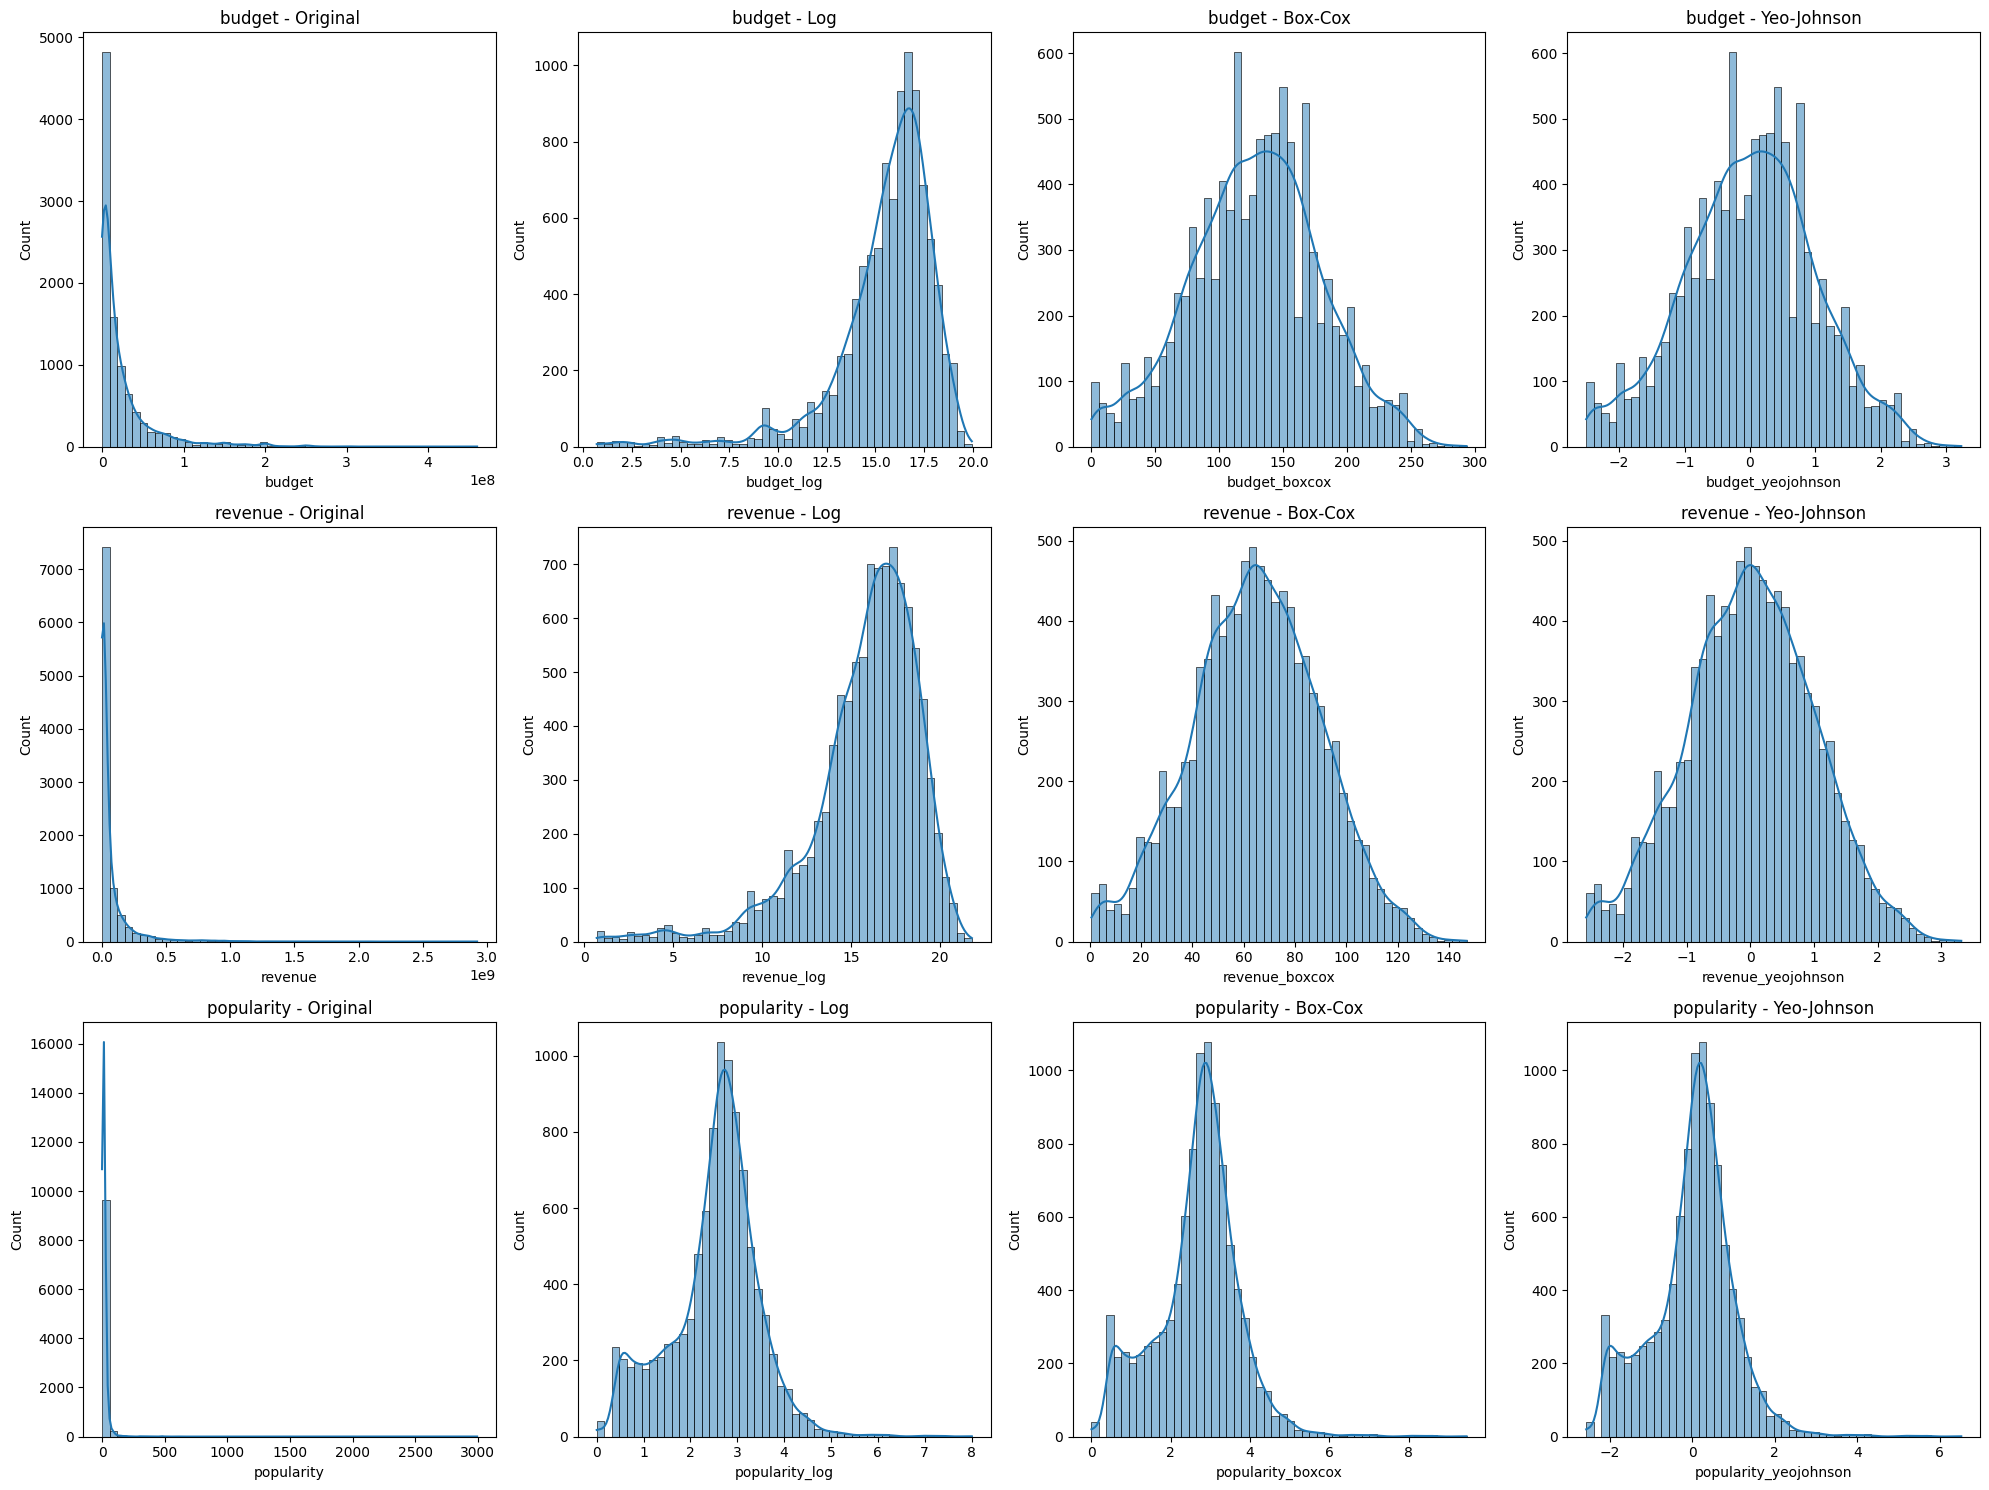

In [31]:
# Comparación de transformaciones estadísticas
variables = [
    'budget',
    'revenue',
    'popularity'
]

transformaciones = [
    '',
    '_log',
    '_boxcox',
    '_yeojohnson'
]

titulos = [
    'Original',
    'Log',
    'Box-Cox',
    'Yeo-Johnson'
]

fig, axes = plt.subplots(
    3,
    4,
    figsize=(20,15)
)

for i, var in enumerate(variables):

    for j, trans in enumerate(transformaciones):

        columna = f'{var}{trans}'

        sns.histplot(
            df_transform[columna],
            bins=50,
            kde=True,
            ax=axes[i,j]
        )

        axes[i,j].set_title(
            f'{var} - {titulos[j]}'
        )

plt.tight_layout()

plt.show()

In [32]:
# Evaluación de asimetría después de transformaciones
variables = [
    'budget',
    'revenue',
    'popularity'
]

transformaciones = [
    '',
    '_log',
    '_boxcox',
    '_yeojohnson'
]

tabla_skewness = pd.DataFrame()

for var in variables:

    for trans in transformaciones:

        columna = f'{var}{trans}'

        nombre = (
            f'{var}{trans}'
            if trans != ''
            else f'{var}_original'
        )

        tabla_skewness.loc[
            nombre,
            'Skewness'
        ] = df_transform[columna].skew()

# Redondear
tabla_skewness = tabla_skewness.round(2)

tabla_skewness

,Skewness
budget_original,3.30
budget_log,-2.18
budget_boxcox,-0.08
budget_yeojohnson,-0.08
revenue_original,5.85
revenue_log,-1.55
revenue_boxcox,-0.05
revenue_yeojohnson,-0.05
popularity_original,28.83
popularity_log,-0.16


Los métodos de escalamiento tradicionales mejoraron la comparabilidad de los datos, pero no resolvieron el problema de la asimetría. Por otro lado, las transformaciones matemáticas, especialmente Box-Cox y Yeo-Johnson, fueron más efectivas al producir distribuciones más equilibradas y estadísticamente manejables. Esto demuestra que transformar las variables era necesario para reducir el impacto de los outliers y obtener datos más adecuados para análisis y modelos posteriores.

In [33]:
# Detección de valores atípicos mediante IQR
variables_iqr = [
    'budget',
    'revenue',
    'popularity'
]

tabla_iqr = pd.DataFrame()

for col in variables_iqr:

    Q1 = df_movies[col].quantile(0.25)
    Q3 = df_movies[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df_movies[
        (df_movies[col] < limite_inferior) |
        (df_movies[col] > limite_superior)
    ]

    porcentaje = (
        len(outliers) / len(df_movies)
    ) * 100

    tabla_iqr.loc[col, 'Q1'] = Q1
    tabla_iqr.loc[col, 'Q3'] = Q3
    tabla_iqr.loc[col, 'IQR'] = IQR
    tabla_iqr.loc[col, 'Limite_Inferior'] = limite_inferior
    tabla_iqr.loc[col, 'Limite_Superior'] = limite_superior
    tabla_iqr.loc[col, 'Cantidad_Outliers'] = len(outliers)
    tabla_iqr.loc[col, 'Porcentaje_Outliers'] = porcentaje

tabla_iqr.round(2)

,Q1,Q3,IQR,Limite_Inferior,Limite_Superior,Cantidad_Outliers,Porcentaje_Outliers
budget,2200000.00,28000000.00,25800000.00,-36500000.00,6.670000e+07,941.0,9.48
revenue,2000000.00,59790964.50,57790964.50,-84686446.75,1.464774e+08,1223.0,12.32
popularity,6.86,20.63,13.77,-13.80,4.129000e+01,653.0,6.58


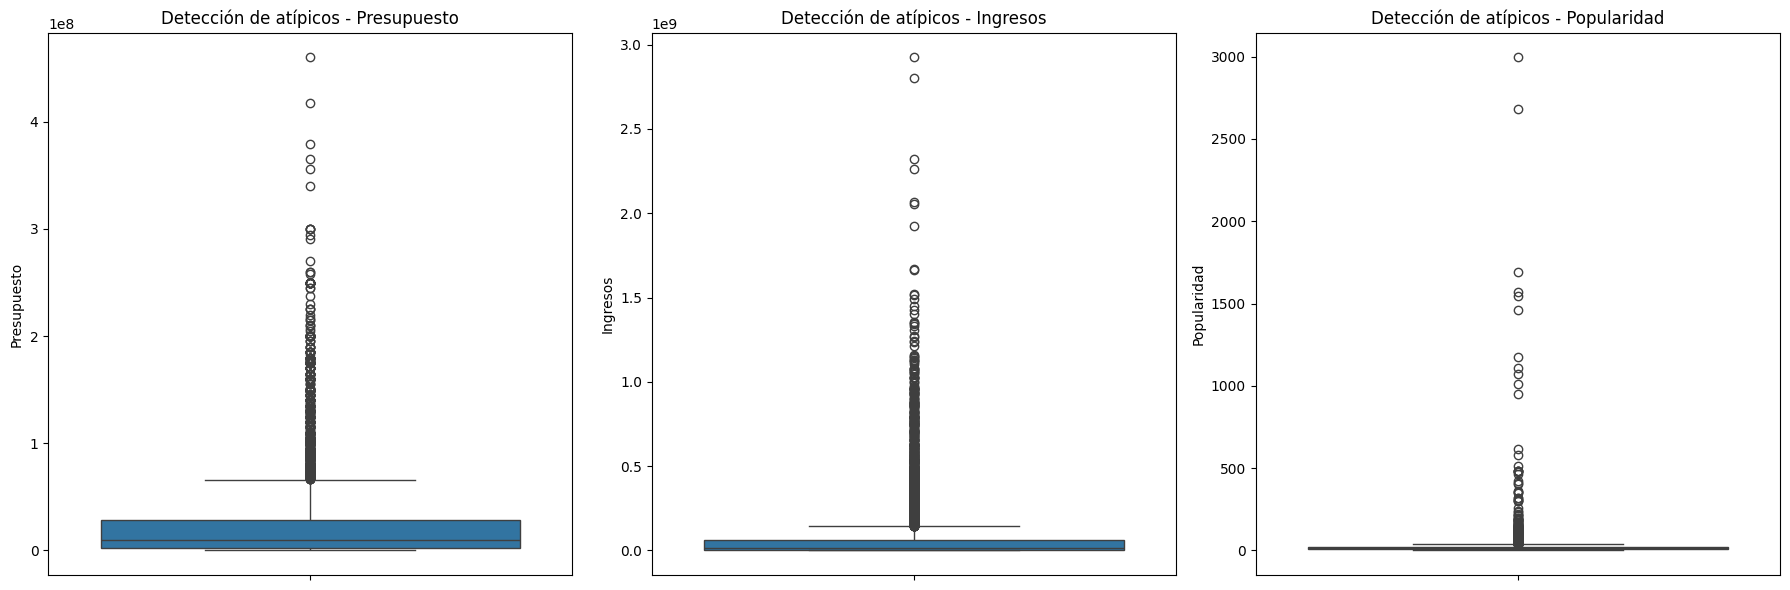

In [34]:
# Visualización de valores atípicos con boxplots
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,6)
)

variables = [
    'budget',
    'revenue',
    'popularity'
]

titulos = [
    'Presupuesto',
    'Ingresos',
    'Popularidad'
]

for i, var in enumerate(variables):

    sns.boxplot(
        y=df_movies[var],
        ax=axes[i]
    )

    axes[i].set_title(
        f'Detección de atípicos - {titulos[i]}'
    )

    axes[i].set_ylabel(
        titulos[i]
    )

plt.tight_layout()

plt.show()

In [35]:
# Cálculo de Z-Score sobre variables transformadas
variables_z = [
    'log_budget',
    'log_revenue',
    'log_popularity'
]

df_zscore = df_movies.copy()

for col in variables_z:

    df_zscore[f'z_{col}'] = zscore(
        df_zscore[col]
    )

In [36]:
# Construcción de tabla resumen de outliers mediante Z-Score
tabla_zscore = pd.DataFrame()

for col in variables_z:

    outliers_z = df_zscore[
        abs(df_zscore[f'z_{col}']) > 3
    ]

    porcentaje = (
        len(outliers_z) / len(df_zscore)
    ) * 100

    tabla_zscore.loc[col, 'Cantidad_Outliers'] = (
        len(outliers_z)
    )

    tabla_zscore.loc[col, 'Porcentaje_Outliers'] = (
        porcentaje
    )

tabla_zscore.round(2)

,Cantidad_Outliers,Porcentaje_Outliers
log_budget,225.0,2.27
log_revenue,190.0,1.91
log_popularity,39.0,0.39


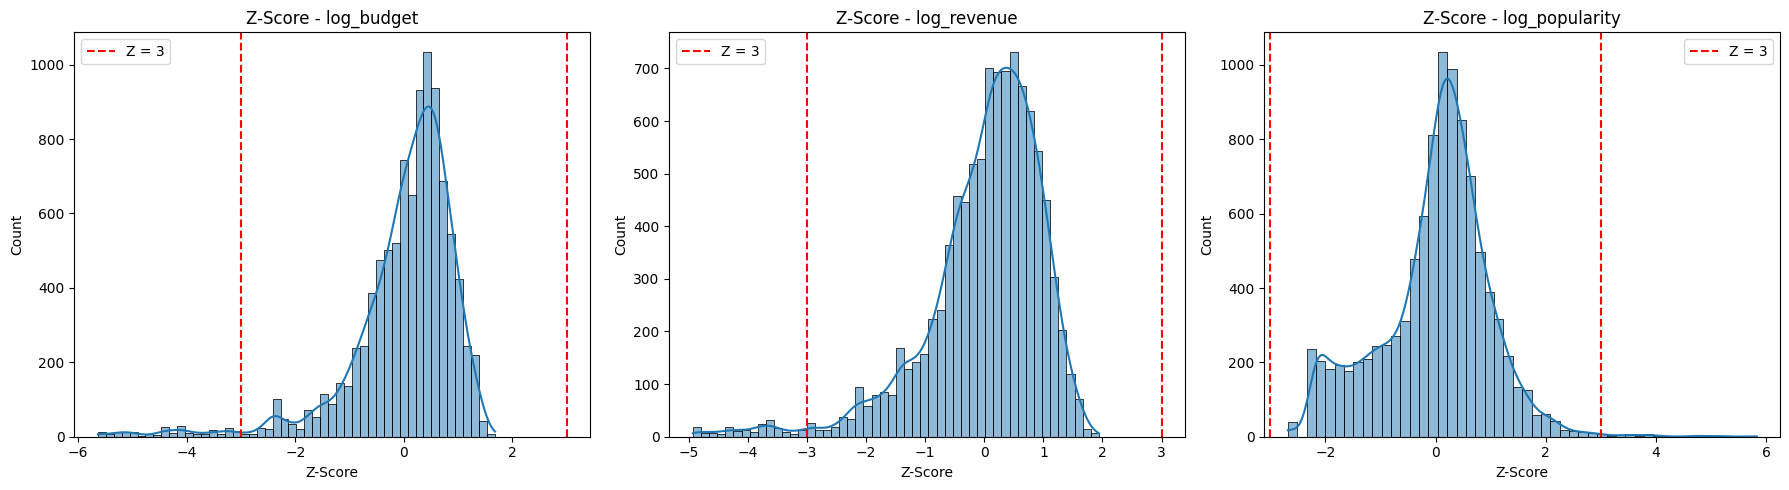

In [37]:
# Visualización de distribuciones Z-Score
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

for i, col in enumerate(variables_z):

    sns.histplot(
        df_zscore[f'z_{col}'],
        bins=50,
        kde=True,
        ax=axes[i]
    )

    axes[i].axvline(
        3,
        color='red',
        linestyle='--',
        label='Z = 3'
    )

    axes[i].axvline(
        -3,
        color='red',
        linestyle='--'
    )

    axes[i].set_title(
        f'Z-Score - {col}'
    )

    axes[i].set_xlabel(
        'Z-Score'
    )

    axes[i].legend()

plt.tight_layout()

plt.show()

In [38]:
# Calcular Z-Score
df_movies['z_budget'] = zscore(df_movies['log_budget'])
df_movies['z_revenue'] = zscore(df_movies['log_revenue'])
df_movies['z_popularity'] = zscore(df_movies['log_popularity'])

# Detectar outliers
df_movies['outlier_budget'] = (
    np.abs(df_movies['z_budget']) > 3
)

df_movies['outlier_revenue'] = (
    np.abs(df_movies['z_revenue']) > 3
)

df_movies['outlier_popularity'] = (
    np.abs(df_movies['z_popularity']) > 3
)

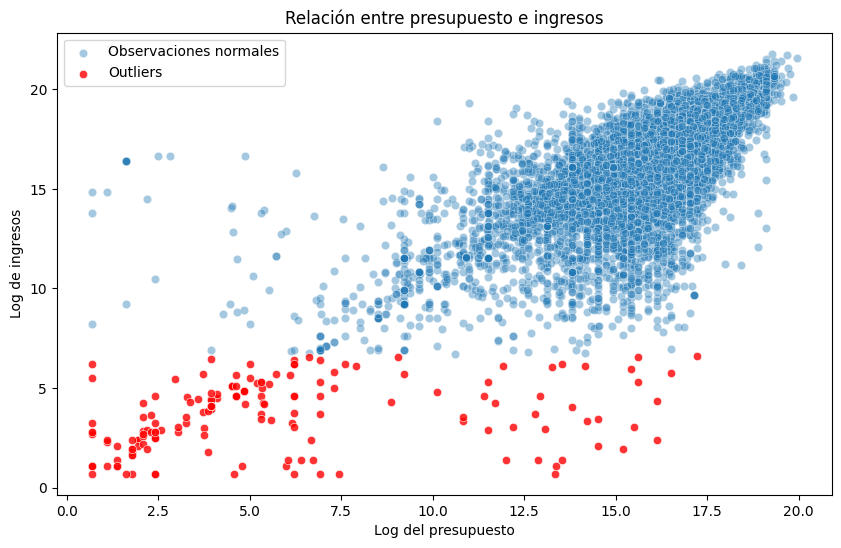

In [39]:
# Relación entre presupuesto e ingresos
plt.figure(figsize=(10,6))

# Películas normales
sns.scatterplot(
    data=df_movies[
        ~df_movies['outlier_revenue']
    ],
    x='log_budget',
    y='log_revenue',
    alpha=0.4,
    label='Observaciones normales'
)

# Outliers
sns.scatterplot(
    data=df_movies[
        df_movies['outlier_revenue']
    ],
    x='log_budget',
    y='log_revenue',
    color='red',
    alpha=0.8,
    label='Outliers'
)

plt.title(
    'Relación entre presupuesto e ingresos'
)

plt.xlabel('Log del presupuesto')

plt.ylabel('Log de ingresos')

plt.legend()

plt.show()

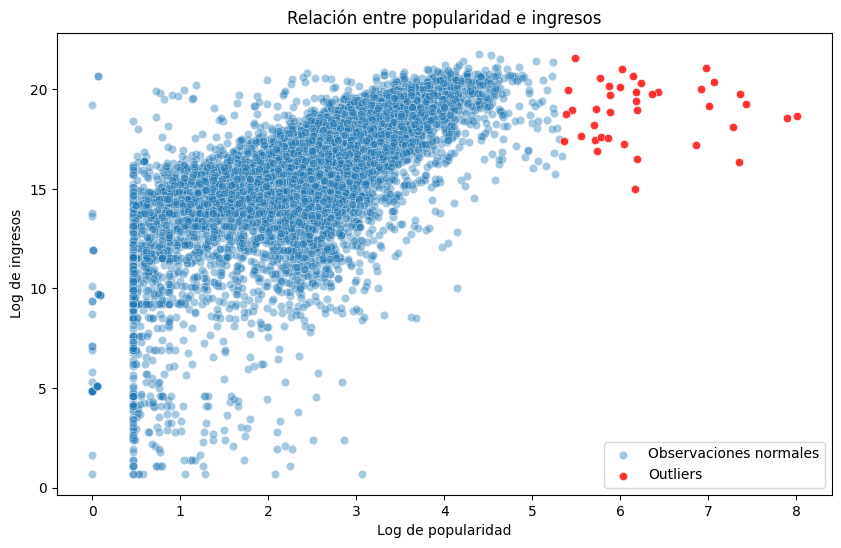

In [40]:
# Relación entre popularidad e ingresos
plt.figure(figsize=(10,6))

# Observaciones normales
sns.scatterplot(
    data=df_movies[
        ~df_movies['outlier_popularity']
    ],
    x='log_popularity',
    y='log_revenue',
    alpha=0.4,
    label='Observaciones normales'
)

# Outliers
sns.scatterplot(
    data=df_movies[
        df_movies['outlier_popularity']
    ],
    x='log_popularity',
    y='log_revenue',
    color='red',
    alpha=0.8,
    label='Outliers'
)

plt.title(
    'Relación entre popularidad e ingresos'
)

plt.xlabel('Log de popularidad')

plt.ylabel('Log de ingresos')

plt.legend()

plt.show()

In [41]:
# Conteo total de observaciones atípicas
print(
    "Outliers budget:",
    df_movies['outlier_budget'].sum()
)

print(
    "Outliers revenue:",
    df_movies['outlier_revenue'].sum()
)

print(
    "Outliers popularity:",
    df_movies['outlier_popularity'].sum()
)

Outliers budget: 225
Outliers revenue: 190
Outliers popularity: 39


In [42]:
# Identificación de películas extremas
outliers_extremos = df_movies[
    df_movies['outlier_revenue']
][[
    'title',
    'budget',
    'revenue',
    'popularity',
    'vote_average'
]].sort_values(
    by='revenue',
    ascending=False
)

outliers_extremos.head(10)

,title,budget,revenue,popularity,vote_average
9757,Far Cry,30000000,743,9.452,3.660
49981,The Point Men,6100000,714,5.013,4.200
106930,Blue Fin,750,703,2.954,6.000
63369,Today Match at 3,8616,702,0.847,6.700
17996,Kaili Blues,50,646,7.260,7.158
162800,Moles,500,600,0.973,7.000
388402,Jockstrap Slaughterhouse,1000,600,0.600,0.000
233877,New York Masalı,1,500,0.627,1.000
430951,One Day: A Musical,2000,500,0.600,0.000
236060,Soft Bullets,500,500,0.637,7.000


In [43]:
# Variables para clustering
variables_cluster = [
    'log_budget',
    'log_revenue',
    'log_popularity'
]

# DataFrame para clustering
df_cluster = df_movies[variables_cluster].copy()

# Escalamiento
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_cluster)

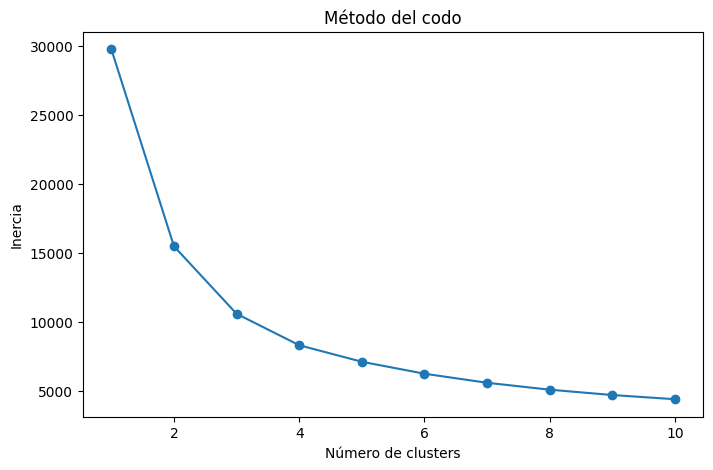

In [44]:
# Método del codo para selección de clusters
inertia = []

K = range(1, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

# Gráfica
plt.figure(figsize=(8,5))

plt.plot(
    K,
    inertia,
    marker='o'
)

plt.title('Método del codo')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')

plt.show()

In [45]:
# Aplicación del algoritmo K-Means
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_movies['cluster'] = kmeans.fit_predict(X_scaled)

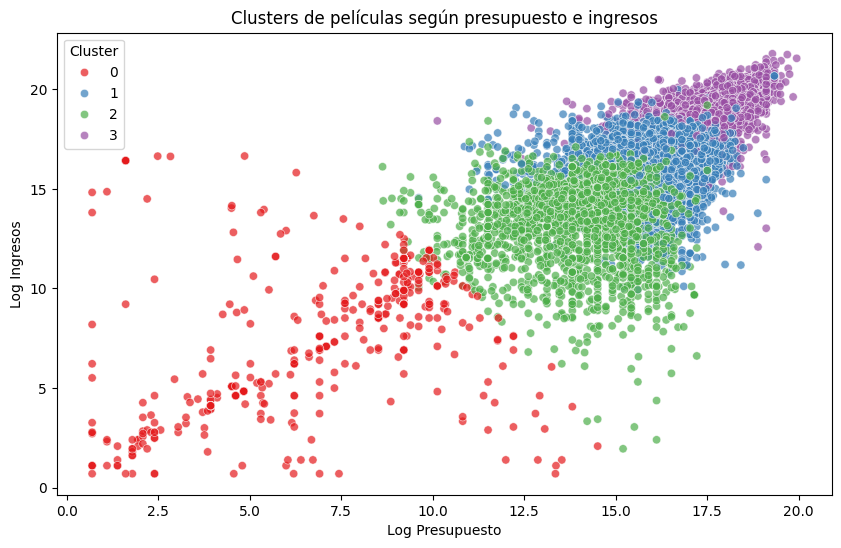

In [46]:
# Visualización de clusters: presupuesto vs ingresos
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_movies,
    x='log_budget',
    y='log_revenue',
    hue='cluster',
    palette='Set1',
    alpha=0.7
)

plt.title('Clusters de películas según presupuesto e ingresos')
plt.xlabel('Log Presupuesto')
plt.ylabel('Log Ingresos')

plt.legend(title='Cluster')

plt.show()

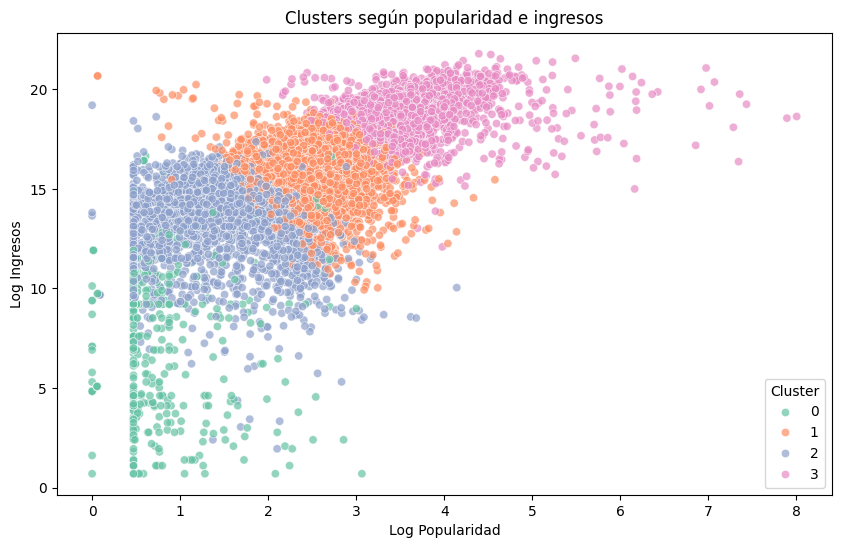

In [47]:
# Visualización de clusters: popularidad vs ingresos
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_movies,
    x='log_popularity',
    y='log_revenue',
    hue='cluster',
    palette='Set2',
    alpha=0.7
)

plt.title('Clusters según popularidad e ingresos')
plt.xlabel('Log Popularidad')
plt.ylabel('Log Ingresos')

plt.legend(title='Cluster')

plt.show()

In [48]:
# Resumen estadístico por cluster
cluster_summary = df_movies.groupby('cluster')[[
    'budget',
    'revenue',
    'popularity'
]].mean().round(2)

cluster_summary

,budget,revenue,popularity
cluster,,,
0,26906.67,3.353988e+05,1.71
1,13520449.43,2.068691e+07,13.36
2,2636564.50,2.210581e+06,4.43
3,58626475.95,1.940009e+08,42.38


El análisis de datos atípicos evidenció la presencia de valores extremos principalmente en las variables de presupuesto e ingresos, lo cual resulta coherente con la naturaleza altamente desigual de la industria cinematográfica, donde unas pocas producciones concentran gran parte de la inversión y recaudación global. Mediante el método IQR se identificó una proporción considerable de observaciones extremas, especialmente en revenue (12.32%). Sin embargo, tras aplicar transformaciones sobre las variables sesgadas y utilizar Z-Score sobre las versiones transformadas, la cantidad de outliers disminuyó notablemente, indicando que gran parte de los extremos iniciales estaban asociados a la asimetría de las distribuciones y no necesariamente a inconsistencias en los datos. Adicionalmente, los análisis multivariados mediante scatterplots y clustering con K-Means permitieron identificar grupos diferenciados de películas según su comportamiento financiero y de popularidad, así como detectar casos particulares con comportamientos anómalos respecto a su presupuesto o rendimiento en taquilla.

In [49]:
# Identificación de valores faltantes
missing = pd.DataFrame({
    'Missing': df_movies.isnull().sum(),
    'Porcentaje': (
        df_movies.isnull().mean() * 100
    )
})

missing = missing[
    missing['Missing'] > 0
].sort_values(
    by='Porcentaje',
    ascending=False
)

missing.round(2)

,Missing,Porcentaje
homepage,6614,66.65
tagline,1971,19.86
keywords,1047,10.55
backdrop_path,595,6.00
production_companies,393,3.96
production_countries,251,2.53
writers,141,1.42
spoken_languages,110,1.11
poster_path,81,0.82
genres,56,0.56


#Variables MNAR:
- homepage
- tagline
- keywords

Estas variables presentan porcentajes elevados de datos faltantes y su ausencia no parece aleatoria. En muchos casos, las películas independientes, antiguas o de bajo presupuesto no cuentan con una web oficial, eslogan comercial o palabras clave registradas. Esto sugiere que la ausencia de información está relacionada con características propias de la película, especialmente su nivel de producción y comercialización.

#Variables MAR
- production_companies
- production_countries
- spoken_languages
- writers
- cast
- directors
- genres

Estas variables presentan porcentajes bajos o moderados de valores faltantes. En estos casos, la ausencia de información podría depender de factores externos como antigüedad de la película, calidad del registro, fuente y/o diferencias entre plataformas de metadatos. La ausencia no parece depender directamente del valor de la variable en sí, sino de otras características observables del conjunto de datos.

#Variables MCAR
- release_date
- release_year
- overview
- poster_path
- backdrop_path

presentan porcentajes muy bajos de datos faltantes. En estos casos, la ausencia parece ser debido a errores de captura, problemas de sincronización entre bases de datos y/o registros incompletos sin un patrón evidente. Debido a esto, se puede considerar que los valores faltantes ocurren de manera aleatoria.

In [50]:
df_movies.to_csv(
    'Base_de_datos_procesada.csv',
    index=False
)

In [51]:
from google.colab import files

files.download('Base_de_datos_procesada.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>